In [1]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [2]:
df=pd.read_csv(r'C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv')

In [3]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')


Origin 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  MAE=1351.74 | RMSE=1703.14 | MAPE=10.23%

Origin 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  MAE=1098.37 | RMSE=1363.59 | MAPE=8.13%

Origin 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  MAE=2460.36 | RMSE=3035.11 | MAPE=25.94%

Origin 4/6 — 2025-10-01
  Train rows: 23928 | Test rows: 744
  MAE=636.86 | RMSE=796.65 | MAPE=8.19%

Origin 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720
  MAE=604.67 | RMSE=769.62 | MAPE=7.21%

Origin 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744
  MAE=980.68 | RMSE=1114.16 | MAPE=11.45%

HW Walk-Forward Results
MAE  = 1185.04 MW
RMSE = 1648.20 MW
MAPE = 11.81 %

Monthly metrics:
  origin_month  n_hours          MAE         RMSE       MAPE
0      2025-07      744  1351.739212  1703.138582  10.227694
1      2025-08      744  1098.370570  1363.591441   8.129923
2      2025-09      720  2460.360218  3035.114330  25.941689
3      2025-10      744   636.860253   7

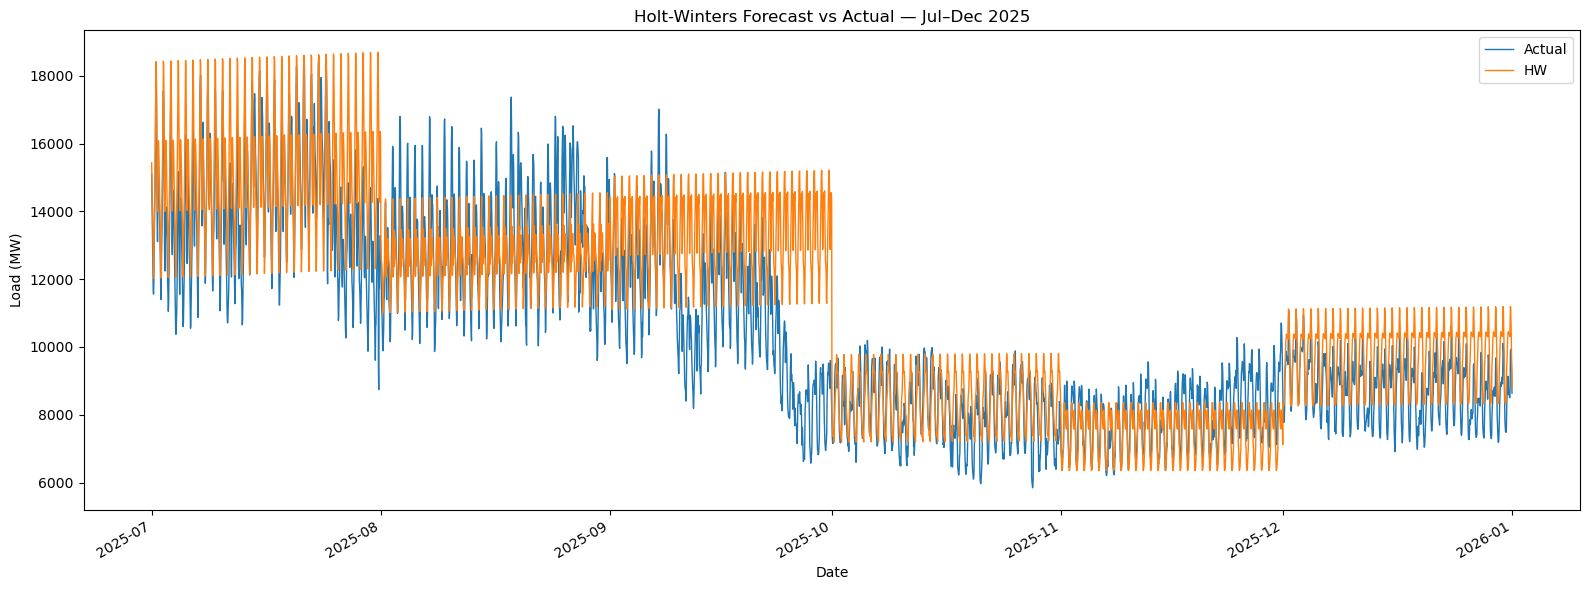

In [4]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"
y = df[target_col]

origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_hw = []
actuals_hw = []
monthly_metrics = []

# ============================================================
# 2) MONTHLY WALK-FORWARD
# ============================================================
for i, origin in enumerate(origins):
    print(f"\n{'='*60}")
    print(f"Origin {i+1}/{len(origins)} — {origin.date()}")

    month_end = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)

    train = y.loc[: origin - pd.Timedelta(hours=1)].dropna()
    actual_month = y.loc[origin:month_end].dropna()

    if len(actual_month) == 0:
        continue

    print(f"  Train rows: {len(train)} | Test rows: {len(actual_month)}")

    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=24
    )

    fit = model.fit(optimized=True)

    forecast = fit.forecast(len(actual_month))
    forecast = pd.Series(forecast.values, index=actual_month.index)

    preds_hw.append(forecast)
    actuals_hw.append(actual_month)

    # monthly metrics
    mae_m = np.mean(np.abs(actual_month - forecast))
    rmse_m = np.sqrt(np.mean((actual_month - forecast) ** 2))
    mape_m = np.mean(np.abs((actual_month - forecast) / actual_month)) * 100

    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(actual_month),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    print(f"  MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%")

# ============================================================
# 3) OVERALL METRICS
# ============================================================
pred_hw = pd.concat(preds_hw).sort_index()
actual_hw = pd.concat(actuals_hw).sort_index()

mae = np.mean(np.abs(actual_hw - pred_hw))
rmse = np.sqrt(np.mean((actual_hw - pred_hw) ** 2))
mape = np.mean(np.abs((actual_hw - pred_hw) / actual_hw)) * 100

print(f"\nHW Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 4) TABLES
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)

print("\nMonthly metrics:")
print(monthly_metrics_df)

monthly_metrics_df.to_csv("hw_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_hw,
    "predicted": pred_hw
})
pred_vs_actual_df.to_csv("hw_predictions.csv")

# ============================================================
# 5) PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(actual_hw.index, actual_hw.values, label="Actual", linewidth=1.0)
ax.plot(pred_hw.index, pred_hw.values, label="HW", linewidth=1.0)

ax.set_title("Holt-Winters Forecast vs Actual — Jul–Dec 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [5]:

# ============================================================
# 6) MLFLOW
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

with mlflow.start_run(run_name="HW_walkforward_monthly"):
    mlflow.log_param("model", "Holt-Winters")
    mlflow.log_param("trend", "add")
    mlflow.log_param("seasonal", "add")
    mlflow.log_param("seasonal_periods", 24)
    mlflow.log_param("refit_frequency", "monthly")

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)

    mlflow.log_artifact("hw_monthly_metrics.csv")
    mlflow.log_artifact("hw_predictions.csv")

    fig.savefig("hw_forecast.png")
    mlflow.log_artifact("hw_forecast.png")

🏃 View run HW_walkforward_monthly at: http://127.0.0.1:5000/#/experiments/531580567308328190/runs/abf937cedcf3482db5f1efce9f57e0ff
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/531580567308328190



Origin 1/6 — 2025-07-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01


...

  Done — 744 hours forecasted

Origin 5/6 — 2025-11-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 720 hours forecasted

Origin 6/6 — 2025-12-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

Holt-Winters Walk-Forward Results
MAE  = 2721.57 MW
RMSE = 3405.95 MW
MAPE = 28.29 %


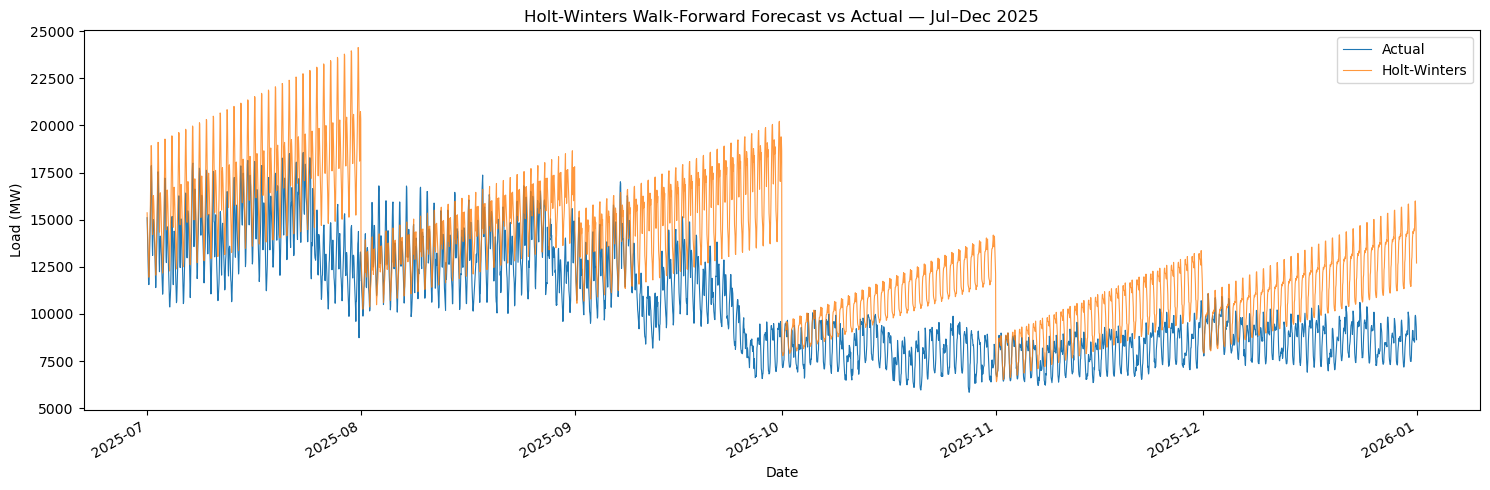

🏃 View run HoltWinters_walkforward at: http://127.0.0.1:5000/#/experiments/4/runs/7113f98cb916435cb2e65623b6cd2842
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [5]:

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Load_Forecasting")

# ── target series (must have DatetimeIndex) ───────────────────
y = df['load']

# ── walk-forward loop ─────────────────────────────────────────
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_hw   = []
actuals_hw = []

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end    = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    train        = y.loc[: origin - pd.Timedelta(hours=1)]
    actual_month = y.loc[origin : month_end]

    model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal='mul',
        seasonal_periods=24,
        initialization_method="estimated"
    ).fit(optimized=True)

    pred_month = model.forecast(len(actual_month))
    pred_month.index = actual_month.index

    preds_hw.append(pred_month)
    actuals_hw.append(actual_month)
    print(f"  Done — {len(actual_month)} hours forecasted")

# ── metrics ───────────────────────────────────────────────────
pred_hw   = pd.concat(preds_hw).sort_index()
actual_hw = pd.concat(actuals_hw).sort_index()

mae  = np.mean(np.abs(actual_hw - pred_hw))
rmse = np.sqrt(np.mean((actual_hw - pred_hw)**2))
mape = np.mean(np.abs((actual_hw - pred_hw) / actual_hw)) * 100

print(f"\nHolt-Winters Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ── plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_hw.index, actual_hw.values, label='Actual', linewidth=0.8)
ax.plot(pred_hw.index, pred_hw.values, label='Holt-Winters', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('Holt-Winters Walk-Forward Forecast vs Actual — Jul–Dec 2025')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── mlflow logging ────────────────────────────────────────────
with mlflow.start_run(run_name="HoltWinters_walkforward"):
    mlflow.log_param("model", "Holt-Winters")
    mlflow.log_param("trend", "add")
    mlflow.log_param("seasonal", "mul")
    mlflow.log_param("seasonal_periods", 24)
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)
    fig.savefig("holtwinters_forecast.png")
    mlflow.log_artifact("holtwinters_forecast.png")